# For one Oklahoma tornado, do the two report archives agree on when and where it was, and what did radar, lightning, and the model analysis show at that place and time?

One reported tornado, six national archives, one manifest, one lockfile. The
notebook starts from the NCEI Storm Events annual archive for 2024, takes the
time and position of event 1184052 out of it rather than assuming them, and
then asks each of the other five sources what it recorded at that time and
place: the Storm Prediction Center's own tornado file, the nearest KTLX Level II
volume scan, five MRMS mid-level rotation grids, twenty minutes of GOES-16
lightning, and the HRRR analysis that ran last before the report.

Every number below comes from a cell in this notebook, and every file comes from
the one [manifest](dataset.yaml) and the lockfile it writes. usdata only
acquires the files; the analysis is pandas, numpy, and xarray.

Requires a source checkout of usdata with the `radar`, `netcdf`, and `grib`
extras, because the notebook uses named manifest sources, `inspect()`, the
strict GRIB2 `select`, registry-filled units, and `usdata cite`, which are
available since v0.17.0. Run every cell in order. The
manifest pins 216.3 MB. Saved outputs are a dated snapshot, not a promise
about future upstream responses: keep the manifest, the lockfile, and the cached
bytes together.

In [1]:
import gc
import subprocess
import sys
import time
from datetime import UTC, datetime, timedelta, timezone
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Geod

from usdata import pull, verify

manifest = Path("dataset.yaml")
if not manifest.is_file():
    manifest = Path("examples/severe-weather-case-study/dataset.yaml")

geod = Geod(ellps="WGS84")
RADIUS_KM = 25.0
HALF_DEGREE = 0.5
notebook_started = time.perf_counter()

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 90

print("Executed UTC:", datetime.now(UTC).isoformat(timespec="seconds"))
print("Python:", sys.version.split()[0])
print(
    {
        name: version(name)
        for name in ("usdata", "pandas", "numpy", "xarray", "xradar", "eccodes", "pyproj")
    }
)

Executed UTC: 2026-09-16T02:11:34+00:00
Python: 3.14.7
{'usdata': '0.16.0', 'pandas': '3.0.5', 'numpy': '2.5.2', 'xarray': '2026.7.0', 'xradar': '0.12.0', 'eccodes': '2.48.0', 'pyproj': '3.8.0'}


## 1. One manifest, six named sources

Every file this notebook touches is declared once, in `dataset.yaml`. Each
source carries a `name`, so the result is addressed by what the source is for
(`reports`, `spc`, `radar`, `rotation`, `lightning`, `environment`) instead of
by its position in a list. `result.by_source["radar"]` returns exactly the
assets that source resolved to, and the lockfile records the same keys, so a
restore rebuilds the grouping without re-resolving anything.

None of these services subsets on the server. Storm Events and the SPC file come
back as whole annual tables, MRMS and GOES-16 as whole CONUS or full-disk files,
and HRRR as a whole 3 km CONUS grid. The window and the product are the only
things the query chooses; every spatial and variable narrowing below happens
locally, after the download.

Before pulling 216 MB, `usdata fetch <dataset> ... --dry-run` lists the matching
assets and their sizes for one source at a time, and the README shows that
listing for each of the six.

In [2]:
print(manifest.read_text().strip())

started = time.perf_counter()
result = pull(manifest)
pull_seconds = time.perf_counter() - started
assert verify(manifest) == []

pinned = pd.DataFrame(
    {
        "source": key,
        "dataset": items[0].asset.dataset_id,
        "assets": len(items),
        "bytes": sum(item.provenance.size or 0 for item in items),
        "first_asset": items[0].asset.id,
    }
    for key, items in result.by_source.items()
)
total_bytes = int(pinned.bytes.sum())
print(f"\nPull seconds: {pull_seconds:.1f}")
print(f"Assets pinned: {len(result.fetched)}")
print(f"Total pinned bytes: {total_bytes:,} ({total_bytes / 1e6:.1f} MB)")
pinned

name: oklahoma-tornado-1184052
sources:
  - name: reports
    dataset: noaa:storm-events
    start: 2024-05-06
    end: 2024-05-06
  - name: spc
    dataset: noaa:spc-tornado-reports
    start: 2024-01-01
    end: 2024-12-31
  - name: radar
    dataset: noaa:nexrad-level2
    start: 2024-05-07T04:34:00Z
    end: 2024-05-07T04:46:00Z
    params:
      site: KTLX
  - name: rotation
    dataset: noaa:mrms
    start: 2024-05-07T04:34:00Z
    end: 2024-05-07T04:42:00Z
    params:
      product: RotationTrackML30min_00.50
  - name: lightning
    dataset: noaa:goes-glm
    start: 2024-05-07T04:29:00Z
    end: 2024-05-07T04:48:59Z
    params:
      satellite: 16
  - name: environment
    dataset: noaa:hrrr
    start: 2024-05-07T04:00:00Z
    end: 2024-05-07T04:00:00Z
    params:
      cycle: 4
      forecast_hour: 0
      file: sfc



Pull seconds: 20.2
Assets pinned: 70
Total pinned bytes: 216,348,344 (216.3 MB)


,source,dataset,assets,bytes,first_asset
0,reports,noaa:storm-events,1,12693243,StormEvents_details-ftp_v1.0_d2024_c20260728.c...
1,spc,noaa:spc-tornado-reports,1,230094,2024_torn.csv
2,radar,noaa:nexrad-level2,2,39708043,KTLX20240507_043427_V06
3,rotation,noaa:mrms,5,926976,MRMS_RotationTrackML30min_00.50_20240507-04340...
4,lightning,noaa:goes-glm,60,29536150,OR_GLM-L2-LCFA_G16_s20241280429000_e2024128042...
5,environment,noaa:hrrr,1,133253838,hrrr.20240507.t04z.wrfsfcf00.grib2


## 2. Which tornado, and exactly when and where

The 2024 annual details archive is one gzipped CSV of every Storm Events record
for the year. It is 12.7 MB, and it is in the manifest so that the case can be
selected from the archive rather than pasted in as constants: the report's
identifier is the only thing this notebook assumes, and the time, the position,
the rating, and the path come out of the file.

The timestamps in the file are local. `CZ_TIMEZONE` says which zone, and this
record says `CST-6`, a fixed offset with no daylight saving, so the conversion is
an addition of six hours and the local evening of 6 May becomes the UTC early
morning of 7 May. Every other source in this notebook is stamped in UTC, so that
one conversion is what makes the rest of the comparison possible.

In [3]:
columns = [
    "EVENT_ID",
    "EVENT_TYPE",
    "STATE",
    "CZ_NAME",
    "CZ_TIMEZONE",
    "BEGIN_DATE_TIME",
    "END_DATE_TIME",
    "BEGIN_LAT",
    "BEGIN_LON",
    "END_LAT",
    "END_LON",
    "TOR_F_SCALE",
    "TOR_LENGTH",
    "TOR_WIDTH",
    "INJURIES_DIRECT",
    "DEATHS_DIRECT",
    "SOURCE",
]
(reports_item,) = result.by_source["reports"]
events = reports_item.open(usecols=columns)
print("Records in the 2024 archive:", len(events))

(report,) = events.loc[events.EVENT_ID.eq("1184052")].to_dict("records")
if report["CZ_TIMEZONE"] != "CST-6":
    raise ValueError(f"Review the timezone before converting: {report['CZ_TIMEZONE']}")
CST = timezone(timedelta(hours=-6))
REPORT_UTC = (
    datetime.strptime(report["BEGIN_DATE_TIME"], "%d-%b-%y %H:%M:%S")
    .replace(tzinfo=CST)
    .astimezone(UTC)
)
END_UTC = (
    datetime.strptime(report["END_DATE_TIME"], "%d-%b-%y %H:%M:%S")
    .replace(tzinfo=CST)
    .astimezone(UTC)
)
LAT, LON = float(report["BEGIN_LAT"]), float(report["BEGIN_LON"])
END_LAT, END_LON = float(report["END_LAT"]), float(report["END_LON"])
_, _, straight_m = geod.inv(LON, LAT, END_LON, END_LAT)

for key, value in report.items():
    print(f"{key:18s} {value}")
print()
print("Report start, local:", report["BEGIN_DATE_TIME"], report["CZ_TIMEZONE"])
print("Report start, UTC:  ", REPORT_UTC.isoformat())
print("Report end, UTC:    ", END_UTC.isoformat())
print(f"Reported duration:   {(END_UTC - REPORT_UTC).total_seconds() / 60:.0f} minutes")
print(f"Start to end on the ground: {straight_m / 1000:.2f} km")
print(
    f"Reported path length: {report['TOR_LENGTH']} miles = {report['TOR_LENGTH'] * 1.609344:.2f} km"
)
print(f"Reported path width: {report['TOR_WIDTH']} yards = {report['TOR_WIDTH'] * 0.9144:.0f} m")

del events
gc.collect();

Records in the 2024 archive: 69801
EVENT_ID           1184052
STATE              OKLAHOMA
EVENT_TYPE         Tornado
CZ_NAME            OKLAHOMA
BEGIN_DATE_TIME    06-MAY-24 22:39:00
CZ_TIMEZONE        CST-6
END_DATE_TIME      06-MAY-24 22:42:00
INJURIES_DIRECT    0
DEATHS_DIRECT      0
SOURCE             NWS Storm Survey
TOR_F_SCALE        EF1
TOR_LENGTH         2.2
TOR_WIDTH          75.0
BEGIN_LAT          35.378
BEGIN_LON          -97.543
END_LAT            35.397
END_LON            -97.512

Report start, local: 06-MAY-24 22:39:00 CST-6
Report start, UTC:   2024-05-07T04:39:00+00:00
Report end, UTC:     2024-05-07T04:42:00+00:00
Reported duration:   3 minutes
Start to end on the ground: 3.52 km
Reported path length: 2.2 miles = 3.54 km
Reported path width: 75.0 yards = 69 m


## 3. Does the Storm Prediction Center's file say the same thing?

The SPC severe weather database is the other national tornado archive. Its 2024
file is 230 kB of plain CSV, one row per tornado when `sg == 1`. It has no
identifier in common with Storm Events, so the match has to be made on date,
position, and time.

The search below filters on the local calendar date derived in the previous
cell, keeps whole-track rows, and ranks every candidate in the country by
distance from the reported start point. SPC times are Central Standard Time for
every row, whatever zone the tornado was in, which the `tz` code of `3` states,
so the same six-hour addition converts them.

In [4]:
(spc_item,) = result.by_source["spc"]
spc = spc_item.open(dtype={"stf": "string", "f1": "string"})
local_date = REPORT_UTC.astimezone(CST).strftime("%Y-%m-%d")
print("SPC rows in 2024:", len(spc), "| whole-track rows:", int(spc.sg.eq(1).sum()))

candidates = spc.loc[spc.date.eq(local_date) & spc.sg.eq(1)].copy()
_, _, candidate_m = geod.inv(
    np.full(len(candidates), LON),
    np.full(len(candidates), LAT),
    candidates.slon.values,
    candidates.slat.values,
)
candidates["km_from_report"] = np.round(candidate_m / 1000, 2)
candidates = candidates.sort_values("km_from_report")
print(f"Whole-track tornadoes dated {local_date}: {len(candidates)}")
print(
    candidates.head(3)[
        ["om", "st", "time", "tz", "mag", "slat", "slon", "len", "wid", "km_from_report"]
    ].to_string(index=False)
)

spc_match = candidates.iloc[0]
if int(spc_match["tz"]) != 3:
    raise ValueError(f"Review the SPC timezone code before converting: {spc_match['tz']}")
spc_utc = (
    datetime.strptime(f"{spc_match['date']} {spc_match['time']}", "%Y-%m-%d %H:%M:%S")
    .replace(tzinfo=CST)
    .astimezone(UTC)
)
agreement = pd.DataFrame(
    [
        {
            "quantity": "start time (UTC)",
            "storm_events": REPORT_UTC.isoformat(),
            "spc": spc_utc.isoformat(),
        },
        {
            "quantity": "start latitude (degrees north)",
            "storm_events": LAT,
            "spc": float(spc_match["slat"]),
        },
        {
            "quantity": "start longitude (degrees east)",
            "storm_events": LON,
            "spc": float(spc_match["slon"]),
        },
        {
            "quantity": "rating",
            "storm_events": report["TOR_F_SCALE"],
            "spc": f"EF{int(spc_match['mag'])}",
        },
        {
            "quantity": "path length (miles)",
            "storm_events": report["TOR_LENGTH"],
            "spc": float(spc_match["len"]),
        },
        {
            "quantity": "path width (yards)",
            "storm_events": report["TOR_WIDTH"],
            "spc": float(spc_match["wid"]),
        },
    ]
)
print()
print(
    f"Separation: {spc_match['km_from_report']:.2f} km, "
    f"{(spc_utc - REPORT_UTC).total_seconds() / 60:.0f} minutes"
)
del spc, candidates
gc.collect()
agreement

SPC rows in 2024: 1873 | whole-track rows: 1791
Whole-track tornadoes dated 2024-05-06: 40
    om st     time  tz  mag   slat    slon  len  wid  km_from_report
623971 OK 22:39:00   3    1 35.378 -97.543  2.2   75            0.00
623972 OK 22:46:00   3    1 35.427 -97.463  1.1   30            9.08
623964 OK 21:56:00   3    0 35.767 -97.016  2.2   50           64.38

Separation: 0.00 km, 0 minutes


,quantity,storm_events,spc
0,start time (UTC),2024-05-07T04:39:00+00:00,2024-05-07T04:39:00+00:00
1,start latitude (degrees north),35.378,35.378
2,start longitude (degrees east),-97.543,-97.543
3,rating,EF1,EF1
4,path length (miles),2.2,2.2
5,path width (yards),75.0,75.0


## 4. The radar volume nearest the report time

The manifest asks KTLX for every Level II volume scan between 04:34 and 04:46
UTC, which is two files of about 20 MB each, and the notebook picks the one whose
scan start is nearest the report time derived in section 2. Picking it here
rather than in the manifest is the point: the choice follows from the archive,
not from a timestamp typed into YAML.

A volume scan is not an instant. The lowest sweep is one rotation of the
antenna, and its rays are stamped over about sixteen seconds. The gate positions
below are computed from the radar's own location, each ray's azimuth, and the
slant range projected onto the ground at the sweep's fixed elevation angle, with
geodesic arithmetic on WGS84 rather than differences of degrees.

In [5]:
volumes = sorted(result.by_source["radar"], key=lambda item: item.asset.time.start)
for volume in volumes:
    offset = (volume.asset.time.start - REPORT_UTC).total_seconds()
    print(
        f"{volume.asset.id}  scan start {volume.asset.time.start:%H:%M:%S} UTC"
        f"  {offset:+.0f} s from the report"
    )

chosen = min(volumes, key=lambda item: abs((item.asset.time.start - REPORT_UTC).total_seconds()))
scan_offset = (chosen.asset.time.start - REPORT_UTC).total_seconds()
print("\nChosen:", chosen.asset.id)

radar = chosen.open(sweep=0)
sweep = radar["sweep_0"].to_dataset()
radar_lat, radar_lon = float(radar.latitude), float(radar.longitude)
elevation = float(sweep.sweep_fixed_angle)
bearing, _, radar_m = geod.inv(radar_lon, radar_lat, LON, LAT)
effective_radius_km = 4 / 3 * 6371.0
range_km = radar_m / 1000
beam_km = (
    np.sqrt(
        range_km**2
        + effective_radius_km**2
        + 2 * range_km * effective_radius_km * np.sin(np.deg2rad(elevation))
    )
    - effective_radius_km
)
print(f"KTLX at {radar_lat:.4f} N {radar_lon:.4f} E, sweep elevation {elevation:.2f} degrees")
print(f"Report is {range_km:.2f} km from KTLX on a bearing of {bearing % 360:.1f} degrees")
print(f"Beam centre over the report: {beam_km:.2f} km above the radar (4/3 earth refraction)")
print("Sweep rays span", str(sweep.time.min().values), "to", str(sweep.time.max().values))

near = sweep.DBZH.sel(range=slice(None, 90_000))
azimuths = near.azimuth.values
ranges = near.range.values
order = np.argsort(azimuths)
azimuths, reflectivity = azimuths[order], near.values[order]


# Cell boundaries, so pcolormesh takes the mesh as given instead of inferring edges
# from coordinates that turn back on themselves as the antenna sweeps past north.
azimuth_step, range_step = float(np.diff(azimuths).mean()), float(np.diff(ranges).mean())
azimuth_edges = np.concatenate([azimuths - azimuth_step / 2, [azimuths[-1] + azimuth_step / 2]])
range_edges = np.concatenate([ranges - range_step / 2, [ranges[-1] + range_step / 2]])
ground = np.outer(np.ones_like(azimuth_edges), range_edges * np.cos(np.deg2rad(elevation)))
gate_lon, gate_lat, _ = geod.fwd(
    np.full(ground.shape, radar_lon),
    np.full(ground.shape, radar_lat),
    np.outer(azimuth_edges, np.ones_like(range_edges)),
    ground,
)
centre_ground = np.outer(np.ones_like(azimuths), ranges * np.cos(np.deg2rad(elevation)))
centre_lon, centre_lat, _ = geod.fwd(
    np.full(centre_ground.shape, radar_lon),
    np.full(centre_ground.shape, radar_lat),
    np.outer(azimuths, np.ones_like(ranges)),
    centre_ground,
)
_, _, gate_m = geod.inv(
    np.full(centre_ground.shape, LON), np.full(centre_ground.shape, LAT), centre_lon, centre_lat
)
gate_km = gate_m / 1000
in_radius = gate_km <= RADIUS_KM
print(
    f"\nUnits: {near.attrs['units']}; gates kept: {reflectivity.size}, "
    f"within {RADIUS_KM:.0f} km of the report: {int(in_radius.sum())}"
)
max_dbz = float(np.nanmax(np.where(in_radius, reflectivity, np.nan)))
print(f"Maximum reflectivity within {RADIUS_KM:.0f} km: {max_dbz:.1f} dBZ")
del radar, sweep, near
gc.collect();

KTLX20240507_043427_V06  scan start 04:34:27 UTC  -273 s from the report
KTLX20240507_044053_V06  scan start 04:40:53 UTC  +113 s from the report

Chosen: KTLX20240507_044053_V06


KTLX at 35.3334 N -97.2778 E, sweep elevation 0.48 degrees
Report is 24.61 km from KTLX on a bearing of 281.7 degrees
Beam centre over the report: 0.24 km above the radar (4/3 earth refraction)
Sweep rays span 2024-05-07T04:40:53.536000000 to 2024-05-07T04:41:09.636999936

Units: dBZ; gates kept: 253440, within 25 km of the report: 43672
Maximum reflectivity within 25 km: 62.5 dBZ


## 5. Mid-level rotation around the report

MRMS `RotationTrackML30min_00.50` merges azimuthal shear from every radar in the
network over the 3 to 6 km layer and writes a CONUS grid every two minutes. Each
value is the largest shear seen in the thirty minutes ending at the file stamp,
so the grid stamped 04:42 covers 04:12 to 04:42 and is the first one whose window
contains the whole reported tornado.

The files carry no units of their own. The registry entry supplies them, and
`dataset.attrs["usdata"]["registry_attrs"]` lists exactly which attributes were
filled in that way, so a value read out of the file can be printed with a unit
without consulting a web page. The decoded variable is called
`RotationTrackML30min`, without the `_00.50` suffix the manifest must use.

The grids are 7,000 by 14,000 points and about 0.39 GB once decoded, so each one
is cropped to a half-degree box around the report and released before the next is
opened. Values are quantized to whole units of 0.001 per second, so several
cells can tie at a box maximum; the table reports the tie count and averages the
tied positions instead of letting array order choose one.

In [6]:
rotation_rows = []
rotation_field = None
for grid_item in sorted(result.by_source["rotation"], key=lambda item: item.asset.time.start):
    grid = grid_item.open()
    (variable,) = grid.data_vars
    latitudes = grid.latitude.values
    longitudes = grid.longitude.values - 360.0
    rows = np.flatnonzero(np.abs(latitudes - LAT) <= HALF_DEGREE)
    cols = np.flatnonzero(np.abs(longitudes - LON) <= HALF_DEGREE)
    box_lat = latitudes[rows.min() : rows.max() + 1]
    box_lon = longitudes[cols.min() : cols.max() + 1]
    box = grid[variable].values[rows.min() : rows.max() + 1, cols.min() : cols.max() + 1]
    mesh_lon, mesh_lat = np.meshgrid(box_lon, box_lat)
    _, _, cell_m = geod.inv(np.full(box.shape, LON), np.full(box.shape, LAT), mesh_lon, mesh_lat)
    cell_km = cell_m / 1000
    circle = cell_km <= RADIUS_KM
    peak = float(np.max(np.where(circle, box, -np.inf)))
    tied = np.argwhere(circle & (box == peak))
    peak_lat = float(box_lat[tied[:, 0]].mean())
    peak_lon = float(box_lon[tied[:, 1]].mean())
    _, _, peak_m = geod.inv(LON, LAT, peak_lon, peak_lat)
    stamp = grid_item.asset.time.start
    rotation_rows.append(
        {
            "window_utc": f"{(stamp - timedelta(minutes=30)):%H:%M} to {stamp:%H:%M}",
            "peak_in_25km": peak,
            "tied_cells": len(tied),
            "peak_lat": round(peak_lat, 3),
            "peak_lon": round(peak_lon, 3),
            "km_from_report": round(peak_m / 1000, 1),
            "at_report_cell": float(box[np.unravel_index(int(cell_km.argmin()), cell_km.shape)]),
        }
    )
    if stamp.minute == 42:
        rotation_field = (box_lat.copy(), box_lon.copy(), box.copy())
        rotation_units = grid[variable].attrs["units"]
        rotation_name = grid[variable].attrs["long_name"]
        registry_attrs = grid.attrs["usdata"]["registry_attrs"]
        rotation_variable = variable
    del grid, box, cell_km, circle, mesh_lon, mesh_lat
    gc.collect()

rotation = pd.DataFrame(rotation_rows)
print("Decoded variable:", rotation_variable)
print("long_name:", rotation_name)
print("units:", rotation_units)
print("Filled from the registry entry:", registry_attrs)
rotation

Decoded variable: RotationTrackML30min
long_name: 30-minute maximum mid-level azimuthal shear
units: 0.001 s-1
Filled from the registry entry: [{'variable': 'RotationTrackML30min', 'attribute': 'units'}, {'variable': 'RotationTrackML30min', 'attribute': 'long_name'}]


,window_utc,peak_in_25km,tied_cells,peak_lat,peak_lon,km_from_report,at_report_cell
0,04:04 to 04:34,13.0,4,35.349,-97.754,19.4,0.0
1,04:06 to 04:36,13.0,7,35.337,-97.715,16.3,3.0
2,04:08 to 04:38,13.0,7,35.337,-97.715,16.3,3.0
3,04:10 to 04:40,13.0,7,35.337,-97.715,16.3,3.0
4,04:12 to 04:42,18.0,1,35.377,-97.543,0.1,18.0


## 6. Lightning in the twenty minutes around the report

GOES-16's Geostationary Lightning Mapper writes one file every twenty seconds
covering its whole field of view. The manifest pins the sixty files whose start
times fall between 04:29:00 and 04:48:59 UTC, ten minutes either side of the
report, about 30 MB in total.

Flash positions, times, and identifiers arrive as xarray coordinates rather than
data variables, so they have to be promoted with `reset_coords()` before
`to_dataframe()` will keep them. A flash centroid is an energy-weighted
cloud-top position, not a ground strike, and one flash can span several counties
and still count once. The series below is binned on each flash's first
constituent event, which can fall a fraction of a second before the start of the
file it was written into.

Flashes in the whole field of view, 04:29 to 04:49 UTC: 14,897
Within the half-degree box: 479
Within 25 km of the report: 279
Quality flags among those: {0.0: 279}

Mean rate in the ten minutes before the report: 16.4 flashes per minute
Mean rate from the report onward:                 11.5 flashes per minute
Busiest minute: 04:34 UTC with 20 flashes


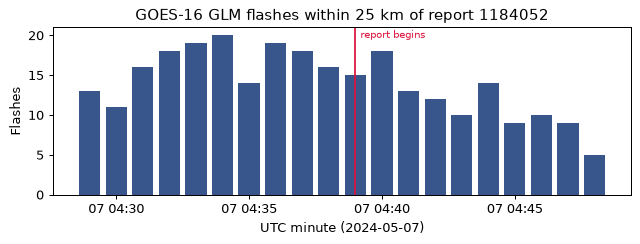

In [7]:
glm_columns = [
    "flash_lat",
    "flash_lon",
    "flash_time_offset_of_first_event",
    "flash_quality_flag",
]
frames = []
for glm_item in sorted(result.by_source["lightning"], key=lambda item: item.asset.time.start):
    detections = glm_item.open()
    frames.append(detections[glm_columns].reset_coords()[glm_columns].to_dataframe())
    detections.close()
    del detections
flashes = pd.concat(frames, ignore_index=True)
_, _, flash_m = geod.inv(
    np.full(len(flashes), LON),
    np.full(len(flashes), LAT),
    flashes.flash_lon.values,
    flashes.flash_lat.values,
)
flashes["km_from_report"] = flash_m / 1000

nearby = flashes.loc[flashes.km_from_report <= RADIUS_KM]
box_flashes = flashes.loc[
    flashes.flash_lat.between(LAT - HALF_DEGREE, LAT + HALF_DEGREE)
    & flashes.flash_lon.between(LON - HALF_DEGREE, LON + HALF_DEGREE)
]
print(f"Flashes in the whole field of view, 04:29 to 04:49 UTC: {len(flashes):,}")
print(f"Within the half-degree box: {len(box_flashes):,}")
print(f"Within {RADIUS_KM:.0f} km of the report: {len(nearby):,}")
print("Quality flags among those:", nearby.flash_quality_flag.value_counts().to_dict())

per_minute = nearby.flash_time_offset_of_first_event.dt.floor("min").value_counts().sort_index()
mark = pd.Timestamp(REPORT_UTC).tz_localize(None)
before, after = per_minute.loc[per_minute.index < mark], per_minute.loc[per_minute.index >= mark]
print(f"\nMean rate in the ten minutes before the report: {before.mean():.1f} flashes per minute")
print(f"Mean rate from the report onward:                 {after.mean():.1f} flashes per minute")
print(f"Busiest minute: {per_minute.idxmax():%H:%M} UTC with {per_minute.max()} flashes")

fig, ax = plt.subplots(figsize=(7.0, 2.6), layout="constrained")
ax.bar(per_minute.index, per_minute.values, width=pd.Timedelta(minutes=0.8), color="#39568c")
ax.axvline(mark, color="crimson", linewidth=1.4)
ax.annotate(
    "report begins",
    xy=(mark, per_minute.max()),
    xytext=(4, -2),
    textcoords="offset points",
    color="crimson",
    fontsize=8,
)
ax.set(
    xlabel="UTC minute (2024-05-07)",
    ylabel="Flashes",
    title=f"GOES-16 GLM flashes within {RADIUS_KM:.0f} km of report 1184052",
)
plt.show()
plt.close(fig)
del frames, flashes
gc.collect();

## 7. The model environment thirty-nine minutes earlier

HRRR runs every hour, and forecast hour 0 of a run is its analysis, the model's
own estimate of the atmosphere at initialization rather than a projection
forward. The last analysis before a 04:39 UTC report is the run initialized at
04:00 UTC, so the manifest pins `cycle: 4`, `forecast_hour: 0`, the surface file:
one 133 MB object holding 170 GRIB2 messages.

`inspect()` returns that inventory as data. Each message reports its
`shortName`, `typeOfLevel`, `level`, `units`, and shape, which is what a `select`
has to be written against, and the table below is just those records in a
DataFrame. The first `open()` call deliberately asks for something the file does
not have, `hlcy` at `typeOfLevel: surface`, with `strict=True`, so the mismatch
raises and names the key instead of quietly returning CAPE alone. The two real
opens then each match exactly one message.

In [8]:
(environment,) = result.by_source["environment"]
summary = environment.inspect()
inventory = pd.DataFrame(
    {
        "shortName": message.short_name,
        "typeOfLevel": message.type_of_level,
        "level": message.level,
        "units": message.units,
        "name": message.name,
    }
    for message in summary.grib2.messages
)
print(
    f"{summary.asset_id}: {summary.format.value}, {summary.size:,} bytes, {len(inventory)} messages"
)
print("\nEvery CAPE and helicity message in the file:")
print(inventory.loc[inventory.shortName.isin(["cape", "hlcy"])].to_string())

try:
    environment.open(select={"shortName": ["cape", "hlcy"], "typeOfLevel": "surface"}, strict=True)
except ValueError as exc:
    print("\nstrict=True refuses a select value that matches nothing:")
    print(str(exc).split(";")[0])
    print("(the rest of the message lists the short names that were available)")

started = time.perf_counter()
cape = environment.open(select={"shortName": "cape", "typeOfLevel": "surface"}, strict=True)
helicity = environment.open(
    select={"shortName": "hlcy", "typeOfLevel": "heightAboveGroundLayer", "level": 3000},
    strict=True,
)
analysis_utc = environment.asset.time.start
lead = REPORT_UTC - analysis_utc
print(f"\nDecode seconds: {time.perf_counter() - started:.1f}")
print("Analysis valid:", analysis_utc.isoformat())
print(f"Report follows the analysis by {lead} ({lead.total_seconds() / 60:.0f} minutes)")

latitudes = cape.latitude.values
stored = cape.longitude.values
longitudes = np.where(stored > 180, stored - 360, stored)
rows, cols = np.where((np.abs(latitudes - LAT) <= 0.6) & (np.abs(longitudes - LON) <= 0.75))
window = (slice(rows.min(), rows.max() + 1), slice(cols.min(), cols.max() + 1))
model_lat, model_lon = latitudes[window], longitudes[window]
_, _, model_m = geod.inv(
    np.full(model_lat.shape, LON), np.full(model_lat.shape, LAT), model_lon, model_lat
)
model_km = model_m / 1000
nearest = np.unravel_index(int(model_km.argmin()), model_km.shape)
circle = model_km <= RADIUS_KM
print(
    f"Nearest grid cell: {model_lat[nearest]:.4f} N {model_lon[nearest]:.4f} E, "
    f"{model_km[nearest]:.2f} km from the report (grid spacing is 3 km); "
    f"{int(circle.sum())} cells within {RADIUS_KM:.0f} km"
)

environment_rows = []
for label, dataset in (
    ("surface CAPE", cape),
    ("0-3 km storm-relative helicity", helicity),
):
    (variable,) = dataset.data_vars
    values = dataset[variable].values[window]
    environment_rows.append(
        {
            "field": label,
            "variable": variable,
            "units": dataset[variable].attrs["units"],
            "at_report_cell": round(float(values[nearest]), 1),
            "median_in_25km": round(float(np.median(values[circle])), 1),
            "max_in_25km": round(float(values[circle].max()), 1),
        }
    )
del cape, helicity
gc.collect()
pd.DataFrame(environment_rows)

hrrr.20240507.t04z.wrfsfcf00.grib2: grib2, 133,253,838 bytes, 170 messages

Every CAPE and helicity message in the file:
    shortName              typeOfLevel  level       units                                   name
104      cape                  surface      0    J kg**-1  Convective available potential energy
130      hlcy   heightAboveGroundLayer   3000  m**2 s**-2                Storm relative helicity
131      hlcy   heightAboveGroundLayer   1000  m**2 s**-2                Storm relative helicity
147      cape  pressureFromGroundLayer  18000    J kg**-1  Convective available potential energy
151      cape  pressureFromGroundLayer   9000    J kg**-1  Convective available potential energy
153      cape  pressureFromGroundLayer  25500    J kg**-1  Convective available potential energy
157      cape   heightAboveGroundLayer      0    J kg**-1  Convective available potential energy



strict=True refuses a select value that matches nothing:
select['shortName'] matched no message for 'hlcy'
(the rest of the message lists the short names that were available)



Decode seconds: 0.6
Analysis valid: 2024-05-07T04:00:00+00:00
Report follows the analysis by 0:39:00 (39 minutes)
Nearest grid cell: 35.3693 N -97.5388 E, 1.04 km from the report (grid spacing is 3 km); 221 cells within 25 km


,field,variable,units,at_report_cell,median_in_25km,max_in_25km
0,surface CAPE,cape,J kg**-1,3320.0,3530.0,5010.0
1,0-3 km storm-relative helicity,hlcy,m**2 s**-2,379.0,409.0,658.0


## 8. One picture of what the radars saw

The left panel is the chosen KTLX sweep, cropped to the half-degree box, with the
reported path drawn on it and every GLM flash centroid from the twenty-minute
window shown as a white dot. The right panel is the MRMS grid stamped 04:42, the
thirty-minute mid-level shear maximum whose window contains the report.

The two panels are different quantities on different grids at different times.
Reflectivity is one instant from one radar at a beam height of about a quarter of
a kilometre over the report; the shear field is a half-hour maximum merged from
the whole network in the 3 to 6 km layer. They are drawn side by side because
they share a map, not because they measure the same thing.

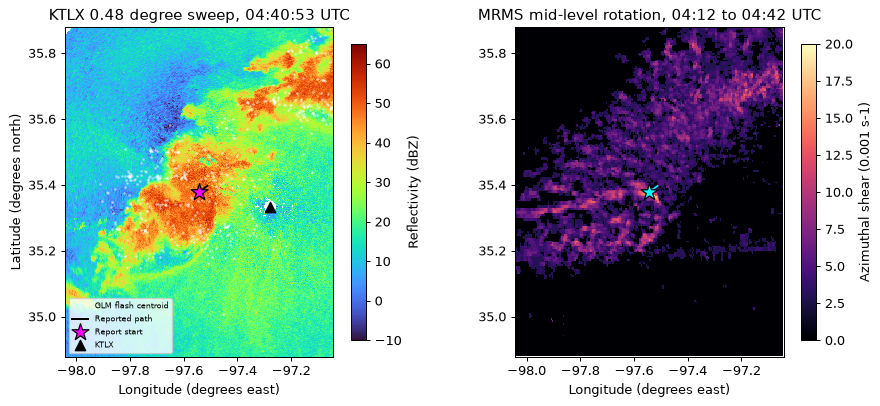

In [9]:
box_lat, box_lon, box_values = rotation_field
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.4), layout="constrained")

ax = axes[0]
mesh = ax.pcolormesh(
    gate_lon, gate_lat, reflectivity, cmap="turbo", shading="flat", vmin=-10, vmax=65
)
ax.scatter(
    box_flashes.flash_lon,
    box_flashes.flash_lat,
    s=4,
    c="white",
    alpha=0.55,
    linewidths=0,
    label="GLM flash centroid",
)
ax.plot([LON, END_LON], [LAT, END_LAT], color="black", linewidth=1.6, label="Reported path")
ax.scatter(
    LON, LAT, marker="*", s=200, c="magenta", edgecolors="black", zorder=5, label="Report start"
)
ax.scatter(radar_lon, radar_lat, marker="^", s=70, c="black", zorder=5, label="KTLX")
ax.legend(loc="lower left", fontsize=6.5)
ax.set(
    xlim=(LON - HALF_DEGREE, LON + HALF_DEGREE),
    ylim=(LAT - HALF_DEGREE, LAT + HALF_DEGREE),
    xlabel="Longitude (degrees east)",
    ylabel="Latitude (degrees north)",
    title=f"KTLX {elevation:.2f} degree sweep, {chosen.asset.time.start:%H:%M:%S} UTC",
    aspect=1 / np.cos(np.deg2rad(LAT)),
)
fig.colorbar(mesh, ax=ax, label="Reflectivity (dBZ)", shrink=0.9)

ax = axes[1]
mesh = ax.pcolormesh(box_lon, box_lat, box_values, cmap="magma", shading="nearest", vmin=0, vmax=20)
ax.scatter(LON, LAT, marker="*", s=200, c="cyan", edgecolors="black", zorder=5)
ax.plot([LON, END_LON], [LAT, END_LAT], color="cyan", linewidth=1.2)
ax.set(
    xlim=(LON - HALF_DEGREE, LON + HALF_DEGREE),
    ylim=(LAT - HALF_DEGREE, LAT + HALF_DEGREE),
    xlabel="Longitude (degrees east)",
    title="MRMS mid-level rotation, 04:12 to 04:42 UTC",
    aspect=1 / np.cos(np.deg2rad(LAT)),
)
fig.colorbar(mesh, ax=ax, label=f"Azimuthal shear ({rotation_units})", shrink=0.9)
plt.show()
plt.close(fig)
del gate_lon, gate_lat, centre_lon, centre_lat, reflectivity, gate_km, in_radius
gc.collect();

## 9. What the six sources add up to

One row per source, each number carried down from the cell that produced it.

In [10]:
answer = pd.DataFrame(
    [
        {
            "source": "reports",
            "dataset": "noaa:storm-events",
            "what it gave": "event 1184052: EF1, 04:39:00 to 04:42:00 UTC, "
            f"{LAT} N {LON} E, {report['TOR_LENGTH']} mi by {report['TOR_WIDTH']} yd, "
            f"{report['INJURIES_DIRECT']} injuries",
        },
        {
            "source": "spc",
            "dataset": "noaa:spc-tornado-reports",
            "what it gave": f"tornado {int(spc_match['om'])}: same start time, "
            f"{spc_match['km_from_report']:.2f} km from the same point, "
            f"EF{int(spc_match['mag'])}, {spc_match['len']} mi by {int(spc_match['wid'])} yd",
        },
        {
            "source": "radar",
            "dataset": "noaa:nexrad-level2",
            "what it gave": f"KTLX sweep starting {scan_offset:+.0f} s from the report, "
            f"beam {beam_km:.2f} km up, "
            f"{max_dbz:.1f} dBZ maximum within {RADIUS_KM:.0f} km",
        },
        {
            "source": "rotation",
            "dataset": "noaa:mrms",
            "what it gave": f"mid-level shear peak {rotation.peak_in_25km.iloc[-1]:.0f} "
            f"({rotation_units}) in the 04:12 to 04:42 window, "
            f"{rotation.km_from_report.iloc[-1]:.1f} km from the reported start",
        },
        {
            "source": "lightning",
            "dataset": "noaa:goes-glm",
            "what it gave": f"{len(nearby):,} flashes within {RADIUS_KM:.0f} km in 20 minutes, "
            f"{before.mean():.1f} per minute before the report and {after.mean():.1f} after",
        },
        {
            "source": "environment",
            "dataset": "noaa:hrrr",
            "what it gave": f"04:00 UTC analysis, {lead.total_seconds() / 60:.0f} minutes early: "
            f"{environment_rows[0]['at_report_cell']:.0f} J/kg surface CAPE and "
            f"{environment_rows[1]['at_report_cell']:.0f} m2/s2 0-3 km helicity at the report cell",
        },
    ]
)
pd.set_option("display.max_colwidth", 150)
answer

,source,dataset,what it gave
0,reports,noaa:storm-events,"event 1184052: EF1, 04:39:00 to 04:42:00 UTC, 35.378 N -97.543 E, 2.2 mi by 75.0 yd, 0 injuries"
1,spc,noaa:spc-tornado-reports,"tornado 623971: same start time, 0.00 km from the same point, EF1, 2.2 mi by 75 yd"
2,radar,noaa:nexrad-level2,"KTLX sweep starting +113 s from the report, beam 0.24 km up, 62.5 dBZ maximum within 25 km"
3,rotation,noaa:mrms,"mid-level shear peak 18 (0.001 s-1) in the 04:12 to 04:42 window, 0.1 km from the reported start"
4,lightning,noaa:goes-glm,"279 flashes within 25 km in 20 minutes, 16.4 per minute before the report and 11.5 after"
5,environment,noaa:hrrr,"04:00 UTC analysis, 39 minutes early: 3320 J/kg surface CAPE and 379 m2/s2 0-3 km helicity at the report cell"


## What the answer does not show

- **The two archives are not two independent observations.** Storm Events and
  the SPC file both derive from the same NWS Storm Data entry for this tornado,
  which is why their start time, coordinates, rating, path length, and path
  width match exactly rather than approximately. Agreement here means the two
  publication paths carried one survey faithfully. It is not corroboration.
- **None of the remote sensing detects a tornado.** Reflectivity, azimuthal
  shear, and flash counts describe a storm. The tornado in this notebook exists
  only because a survey crew wrote it down; every other number is context around
  a point that the survey supplied.
- **The MRMS peak in the report's own cell is a coincidence of resolution, not a
  measurement of the vortex.** The grid is 0.005 degrees, values are quantized to
  whole units of 0.001 per second, and each one is a maximum over the preceding
  thirty minutes, so a peak landing 0.1 km from the reported start point is a
  half-hour accumulation nearest that cell, not shear observed at 04:39.
- **Mid-level shear is not low-level rotation.** This product samples the 3 to
  6 km layer, well above a tornado, and its magnitude depends on how far each
  contributing radar was and at what angle it looked.
- **The lightning rate fell.** Flashes within 25 km ran at 16.4 per minute in the
  ten minutes before the report and 11.5 per minute afterward. Twenty minutes of
  one storm says nothing about whether flash rates generally rise or fall before
  tornadoes, and GLM's detection efficiency varies with viewing angle, cloud
  depth, and flash size.
- **The analysis is thirty-nine minutes early and is model output.** It is the
  closest analysis available before the report, not a measurement at the report,
  and a 3 km grid cell is not the parcel the storm ingested. CAPE and helicity
  are ingredients that occur on many days without tornadoes.
- **One case is one case.** Nothing here supports a claim about tornadoes in
  general, and the six deeper dives linked from the README each examine one of
  these sources across more files than this notebook pins.

## 10. Cite the inputs

`usdata cite` reads the registry and the lockfile. Every dataset comes out with
the citation the agency asks for, its licence and terms, the retrieval dates,
the number of checksummed assets and their total size, and the manifest source
keys involved, as plain text for a methods section or BibTeX for a bibliography.
Nothing is written and nothing is fetched.

In [11]:
usdata_cli = Path(sys.executable).with_name("usdata")
for style in ("text", "bibtex"):
    finished = subprocess.run(
        [str(usdata_cli), "cite", str(manifest), "--format", style],
        capture_output=True,
        text=True,
        check=True,
    )
    print(f"$ usdata cite {manifest} --format {style}")
    print(finished.stdout.rstrip())
    print()

again = pull(manifest)
assert again.from_lockfile and all(item.from_cache for item in again.fetched)
assert verify(manifest) == []
print("Restored from the lockfile:", again.from_lockfile)
print(f"Notebook seconds: {time.perf_counter() - notebook_started:.0f}")

$ usdata cite dataset.yaml --format text
noaa:storm-events
  NOAA National Centers for Environmental Information, Storm Events Database, accessed via usdata
  homepage: https://www.ncei.noaa.gov/access/storm-events-database/
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00510/html
  retrieved: 2026-09-16; 1 checksummed asset (12,693,243 bytes) pinned by usdata 0.16.0
  sources: reports

noaa:spc-tornado-reports
  NOAA/NWS Storm Prediction Center, Severe Weather Database tornado files, accessed via usdata
  homepage: https://www.spc.noaa.gov/wcm/#data
  license: US Government Work (public domain)
  terms: https://www.weather.gov/disclaimer
  retrieved: 2026-09-16; 1 checksummed asset (230,094 bytes) pinned by usdata 0.16.0
  sources: spc

noaa:nexrad-level2
  NEXRAD on AWS was accessed on [date] from https://registry.opendata.aws/noaa-nexrad
  homepage: https://registry.opendata.aws/noaa-nexrad/
  li

$ usdata cite dataset.yaml --format bibtex
@misc{noaa-storm-events,
  title        = {Storm Events Database},
  howpublished = {NOAA National Centers for Environmental Information, Storm Events Database, accessed via usdata},
  note         = {Retrieved 2026-09-16; 1 checksummed asset (12,693,243 bytes) pinned by usdata 0.16.0},
  url          = {https://www.ncei.noaa.gov/access/storm-events-database/},
}

@misc{noaa-spc-tornado-reports,
  title        = {SPC Tornado Reports},
  howpublished = {NOAA/NWS Storm Prediction Center, Severe Weather Database tornado files, accessed via usdata},
  note         = {Retrieved 2026-09-16; 1 checksummed asset (230,094 bytes) pinned by usdata 0.16.0},
  url          = {https://www.spc.noaa.gov/wcm/#data},
}

@misc{noaa-nexrad-level2,
  title        = {NEXRAD Level II Radar},
  howpublished = {NEXRAD on AWS was accessed on [date] from https://registry.opendata.aws/noaa-nexrad},
  note         = {Retrieved 2026-09-16; 2 checksummed assets (39,708,043 